# Práctica: Integración de Indicadores (Salud vs Economía)
## Relación entre Gasto en Salud (% del PIB) y PIB per Cápita (2000 a 2023)

**Materia:** Tópicos de Big Data  
**Propósito:** Demostrar la combinación (`merge`) de dos fuentes distintas de Our World in Data, evaluar su correlación y explorar si los países con mayor ingreso per cápita destinan una mayor proporción de su PIB a la salud.

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np

### 1. Carga de Ambos Datasets

In [2]:
headers = {'User-Agent': 'Our World In Data data fetch/1.0'}

# 1. Total healthcare expenditure (% of GDP)
df_health = pd.read_csv(
    "https://ourworldindata.org/grapher/total-healthcare-expenditure-gdp.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options=headers
)

# 2. GDP per capita
df_gdp = pd.read_csv(
    "https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options=headers
)

# Renombrar columnas
df_health = df_health.rename(columns={
    'entity': 'Pais',
    'code': 'Codigo',
    'year': 'Anio',
    'current_health_expenditure__che__as_percentage_of_gross_domestic_product__gdp__pct': 'Gasto_Salud_Pct_PIB'
})

df_gdp = df_gdp.rename(columns={
    'entity': 'Pais',
    'code': 'Codigo',
    'year': 'Anio',
    'ny_gdp_pcap_pp_kd': 'PIB_Per_Capita',
    'owid_region': 'Region'
})

### 2. Unión de Datasets (Merge por País, Código y Año)

In [3]:
df_merged = pd.merge(
    df_health,
    df_gdp[['Pais', 'Codigo', 'Anio', 'PIB_Per_Capita', 'Region']],
    on=['Pais', 'Codigo', 'Anio'],
    how='inner'
)
print("Dimensiones del dataset combinado:", df_merged.shape)
df_merged.head(5)

Dimensiones del dataset combinado: (4430, 6)


,Pais,Codigo,Anio,Gasto_Salud_Pct_PIB,PIB_Per_Capita,Region
0,Afghanistan,AFG,2002,9.443391,1774.3087,Asia
1,Afghanistan,AFG,2003,8.941258,1815.9282,Asia
2,Afghanistan,AFG,2004,9.808474,1776.9182,Asia
3,Afghanistan,AFG,2005,9.948289,1908.1147,Asia
4,Afghanistan,AFG,2006,10.622766,1929.7239,Asia


### 3. Correlación Estadística

In [4]:
# Calcular correlación de Pearson entre PIB per cápita y % Gasto en Salud
correlacion = df_merged[['PIB_Per_Capita', 'Gasto_Salud_Pct_PIB']].corr()
print("Matriz de Correlación:")
display(correlacion)

Matriz de Correlación:


,PIB_Per_Capita,Gasto_Salud_Pct_PIB
PIB_Per_Capita,1.000000,0.193878
Gasto_Salud_Pct_PIB,0.193878,1.000000


### 4. Gráfica de Dispersión Global (PIB per Cápita vs Gasto en Salud)

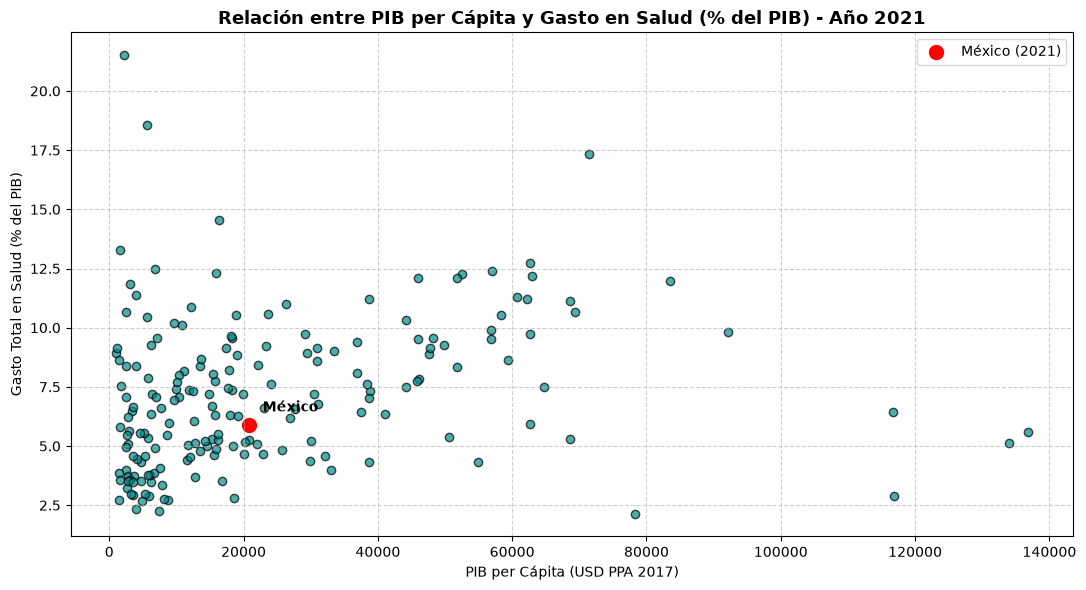

In [5]:
# Datos recientes (2021) para corte transversal
df_2021 = df_merged[df_merged['Anio'] == 2021].dropna(subset=['PIB_Per_Capita', 'Gasto_Salud_Pct_PIB'])

plt.figure(figsize=(11, 6))
plt.scatter(df_2021['PIB_Per_Capita'], df_2021['Gasto_Salud_Pct_PIB'], alpha=0.7, color='darkcyan', edgecolors='k')

# Resaltar México
mex_2021 = df_2021[df_2021['Pais'] == 'Mexico']
if not mex_2021.empty:
    plt.scatter(mex_2021['PIB_Per_Capita'], mex_2021['Gasto_Salud_Pct_PIB'], color='red', s=100, label='México (2021)')
    plt.annotate('México', 
                 (mex_2021['PIB_Per_Capita'].values[0], mex_2021['Gasto_Salud_Pct_PIB'].values[0]),
                 textcoords="offset points", xytext=(10,10), fontweight='bold')

plt.title('Relación entre PIB per Cápita y Gasto en Salud (% del PIB) - Año 2021', fontsize=13, fontweight='bold')
plt.xlabel('PIB per Cápita (USD PPA 2017)')
plt.ylabel('Gasto Total en Salud (% del PIB)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 5. Trayectoria Temporal de México (2000–2023)

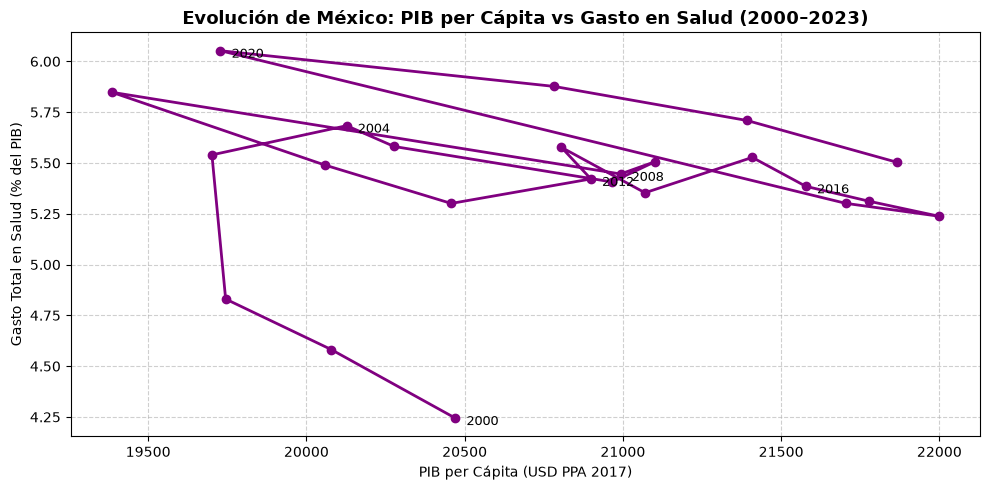

In [6]:
mexico_traj = df_merged[df_merged['Pais'] == 'Mexico'].sort_values('Anio')

plt.figure(figsize=(10, 5))
plt.plot(mexico_traj['PIB_Per_Capita'], mexico_traj['Gasto_Salud_Pct_PIB'], marker='o', color='purple', linewidth=2)

for _, row in mexico_traj.iloc[::4].iterrows():
    plt.annotate(int(row['Anio']), (row['PIB_Per_Capita'], row['Gasto_Salud_Pct_PIB']),
                 textcoords="offset points", xytext=(8, -5), fontsize=9)

plt.title('Evolución de México: PIB per Cápita vs Gasto en Salud (2000–2023)', fontsize=13, fontweight='bold')
plt.xlabel('PIB per Cápita (USD PPA 2017)')
plt.ylabel('Gasto Total en Salud (% del PIB)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()